# Multiaxial Plasticity

{download}`Download <material-0011.ipynb>`

In [ ]:

import numpy as np

# Loading histories: (time, value) pairs
shear = [(0,0), (1,1.2), (3,-1.2), (5,1.2), (6,0), (7,1.2), (9,-1.2), (11,1.2), (12,0), (13,1.2)]
axial = [(0,0), (5,0), (6,0.7), (7,0), (11,0), (12,0.7), (13,0)]

t_s, g_s = map(np.array, zip(*shear))
t_a, e_a = map(np.array, zip(*axial))

nstep = 500
times = np.linspace(0, max(np.max(t_s), np.max(t_a)), nstep)
gamma_xz = np.interp(times, t_s, g_s)
eps_zz   = np.interp(times, t_a, e_a)



In [ ]:

import xara


materials = [
    xara.TriaxialMaterial("GeneralizedJ2",
        E=100.0, nu=0.3, Fy=15.0,
        Hiso=0.0, 
        Hkin=0.0,
        C=10, 
        gamma=9.0,
        Fs=25.0,
        tol=1e-10,
        overstress=25.0, 
        transition=50
    ),

    xara.TriaxialMaterial("NonlinearJ2",
        E=100.0, nu=0.3, Fy=15.0,
        Hiso=0.0, Hkin=0.0,
        C=10, 
        gamma=9.0,
        Q=[10, 0], 
        b=[50, 0],
        Fs=25.0,
        tol=1e-10,
        overstress=25.0, 
        transition=50
    ),
]

## Analysis

In [3]:

def test_erasure(mat):
    tau, sig, gam, eps = [], [], [], []

    # Voigt order: [xx, yy, zz, xy, xz, yz]
    with mat as tmp:
        for i in range(nstep):
            strain = (0.0, 0.0, eps_zz[i], 0.0, gamma_xz[i], 0.0)
            stress = tmp.getStress(strain, commit=True)

            sig.append(stress[2])
            tau.append(stress[4])
            eps.append(strain[2])
            gam.append(strain[4])

    return tau, sig, gam, eps


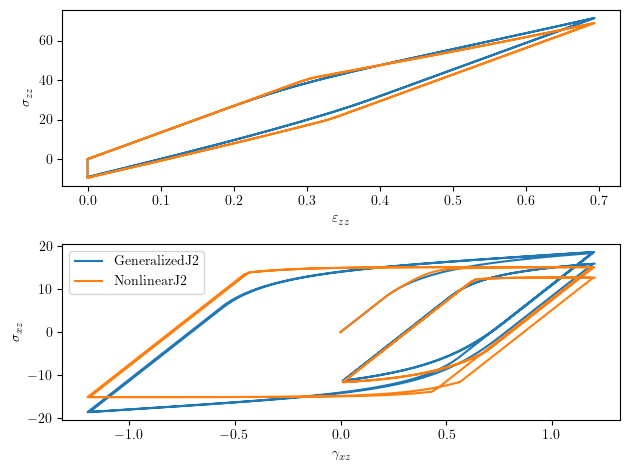

In [4]:


import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1)

for material in materials:

    tau, sig, gam, eps = test_erasure(material)
    ax[0].plot(eps, sig)
    ax[1].plot(gam, tau, label=material.type)


ax[1].set_ylabel(r'$\sigma_{xz}$')
ax[1].set_xlabel(r'$\gamma_{xz}$')
ax[0].set_ylabel(r'$\sigma_{zz}$')
ax[0].set_xlabel(r'$\varepsilon_{zz}$')
ax[1].legend()
plt.tight_layout()

## References

- Auricchio, F., and R.L. Taylor. 
  “Two Material Models for Cyclic Plasticity: Nonlinear Kinematic Hardening and Generalized Plasticity.” 
  International Journal of Plasticity 11, no. 1 (1995): 65–98. 
  https://doi.org/10.1016/0749-6419(94)00039-5.
